In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [78]:
retornos_portfolio = pd.read_csv('ret_acumulado_portfolio.csv', index_col=0, parse_dates=True).squeeze()
retornos_log_portfolio = np.log(retornos_portfolio) - np.log(retornos_portfolio.shift(1))
zscore = ((retornos_log_portfolio - retornos_log_portfolio.mean()) / retornos_log_portfolio.std()).dropna()
# O z-score mostra quantos desvios padrão um valor está da média.

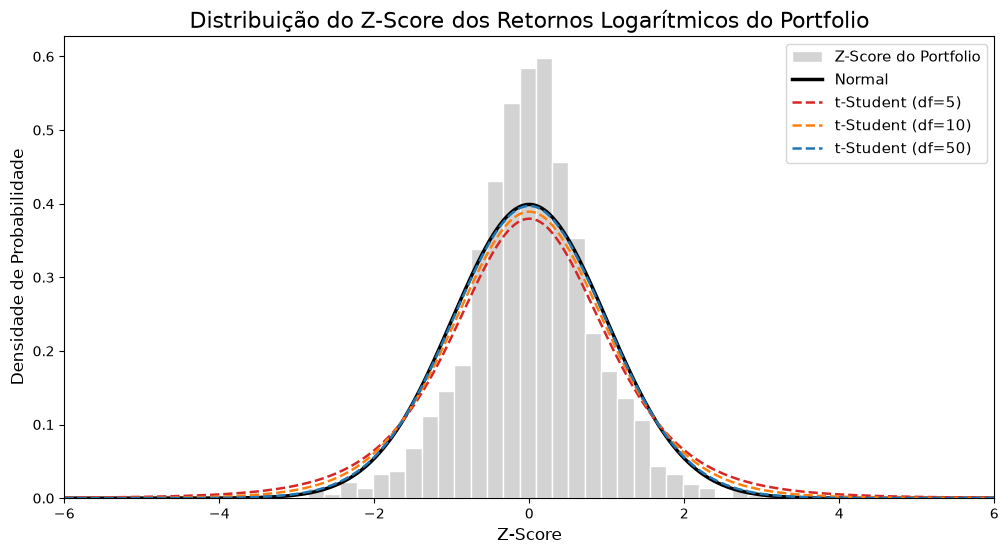

In [79]:
x = np.linspace(-6, 6, 500)

plt.figure(figsize=(12, 6))
plt.hist(zscore, bins=100, density=True, color='lightgray', edgecolor='white', label='Z-Score do Portfolio')
plt.plot(x, stats.norm.pdf(x), color='black', linewidth=2.5, label='Normal')
plt.plot(x, stats.t.pdf(x, df=5), color='tab:red', linewidth=1.8, linestyle='--', label='t-Student (df=5)')
plt.plot(x, stats.t.pdf(x, df=10), color='tab:orange', linewidth=1.8, linestyle='--', label='t-Student (df=10)')
plt.plot(x, stats.t.pdf(x, df=50), color='tab:blue', linewidth=1.8, linestyle='--', label='t-Student (df=50)')
plt.title('Distribuição do Z-Score dos Retornos Logarítmicos do Portfolio', fontsize=16)
plt.xlabel('Z-Score', fontsize=12)
plt.ylabel('Densidade de Probabilidade', fontsize=12)
plt.xlim(-6, 6)
plt.legend(fontsize=11)
plt.show()

# A curva t-student difere da normal, pois apresenta caudas mais pesadas, ou seja, há maior probabilidade de ocorrerem valores extremos.

In [80]:
prob_3 = 1 - stats.norm.cdf(0.03, loc=retornos_log_portfolio.mean(), scale=retornos_log_portfolio.std())

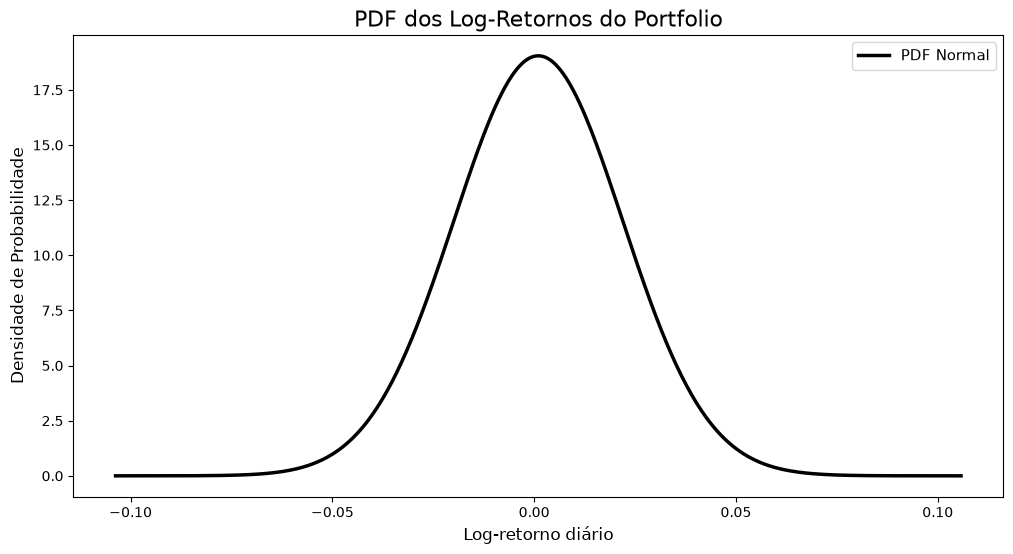

In [81]:
media = retornos_log_portfolio.mean()
desvio = retornos_log_portfolio.std()

x_ret = np.linspace(media - 5*desvio, media + 5*desvio, 500)
pdf_logret = stats.norm.pdf(x_ret, loc=media, scale=desvio)

plt.figure(figsize=(12, 6))
plt.plot(x_ret, pdf_logret, color='black', linewidth=2.5, label='PDF Normal')
plt.title('PDF dos Log-Retornos do Portfolio', fontsize=16)
plt.xlabel('Log-retorno diário', fontsize=12)
plt.ylabel('Densidade de Probabilidade', fontsize=12)
plt.legend(fontsize=11)
plt.show()

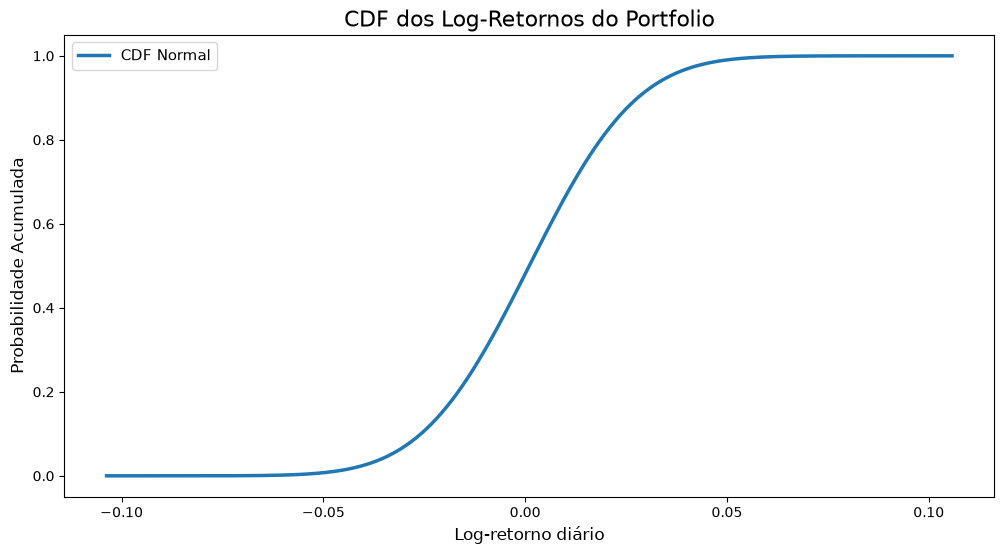

In [82]:
cdf_logret = stats.norm.cdf(x_ret, loc=media, scale=desvio)

plt.figure(figsize=(12, 6))
plt.plot(x_ret, cdf_logret, color='tab:blue', linewidth=2.5, label='CDF Normal')
plt.title('CDF dos Log-Retornos do Portfolio', fontsize=16)
plt.xlabel('Log-retorno diário', fontsize=12)
plt.ylabel('Probabilidade Acumulada', fontsize=12)
plt.legend(fontsize=11)
plt.show()

In [83]:
kurtosis = retornos_log_portfolio.kurtosis() + 3  # Adicionando 3 para obter a curtose total
skewness = retornos_log_portfolio.skew()
# A kurtosis mostra o quão prováveis são os valores extremos na distribuição, ou seja, o quão grossa a cauda é. A skewness mostra a assimetria da distribuição, ou seja, se há cauda, e se ela é maior à esquerda ou à direita.
# Os valores pra uma normal padrão são 0 de skewness e 3 de kurtosis.
# A diferença do kurtosis do meu portfolio para o kurtosis de uma normal é 23, ou seja, a cauda do meu portfolio é muito mais grossa que a da normal.
# A diferença do skewness do meu portfolio para o skewness de uma normal é -1,73, ou seja, meu portfolio apresenta uma cauda maior na esquerda.

In [84]:
prob_negativo = stats.norm.cdf(0, loc=media, scale=desvio)
prob_25 = stats.norm.ppf(0.25, loc=media, scale=desvio)

In [ ]:
pico = retornos_portfolio.cummax()
drawdown = (retornos_portfolio / pico) - 1
max_drawdown = drawdown.min()
data_max_drawdown = drawdown.idxmin()
# O máximo drawdown é a maior perda do portfolio em relação ao seu pico até o momento. Visto que o máximo drawdown do meu portfolio é de -0,566, meu portfolio perdeu 56,6% do valor em relação ao pico em 23/03/2020.

In [ ]:
retornos_ibov = pd.read_csv('ret_acumulado_ibov.csv', index_col=0, parse_dates=True).squeeze()
retornos_log_ibov = np.log(retornos_ibov) - np.log(retornos_ibov.shift(1))
print(stats.ttest_1samp(retornos_log_portfolio.dropna(), 0)) # Teste 1
print(stats.ttest_rel(retornos_log_portfolio.dropna(), retornos_log_ibov.dropna())) # Teste 2
# Utilizando alpha de 0,05, por padrão, descartamos a hipótese nula do teste 1, visto que 0,0165 < 0,05. Portanto, os retornos do portfolio são estatisticamente diferentes de zero.
# Utilizando alpha de 0,05, por padrão, rejeitamos a hipótese nula do teste 2, visto que 0,0279 < 0,05. Portanto, os retornos do portfolio são estatisticamente diferentes dos retornos do IBOV.

TtestResult(statistic=np.float64(2.3994237894162973), pvalue=np.float64(0.01649617307401327), df=np.int64(2417))
TtestResult(statistic=np.float64(2.1992912986375255), pvalue=np.float64(0.027951609447592084), df=np.int64(2417))
